In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cv2
import os
import glob
from skimage import io, color
from skimage.feature import graycomatrix, graycoprops
from skimage import io, color
from skimage.util import img_as_ubyte

In [2]:
dir = 'data_labeling\\src\\raw_images'
segment_files = glob.glob(os.path.join(dir, '*.tif'))
img = io.imread(segment_files[1])

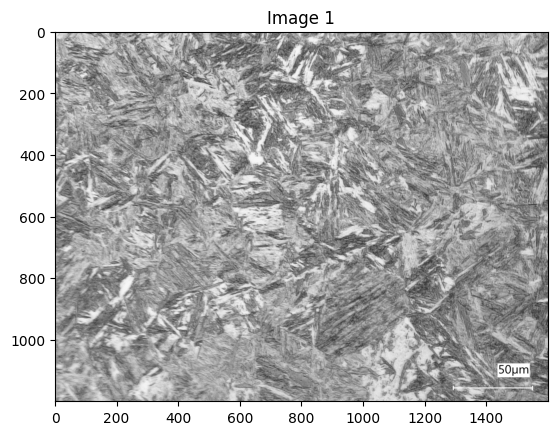

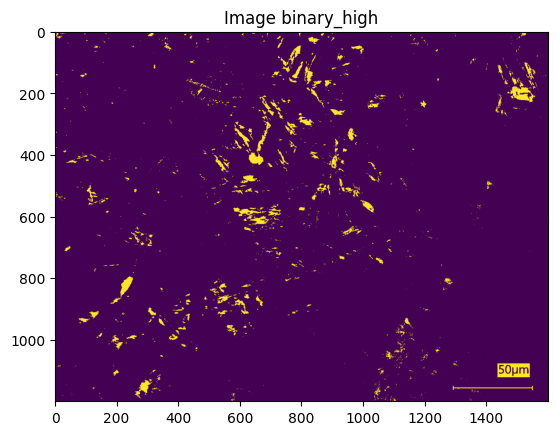

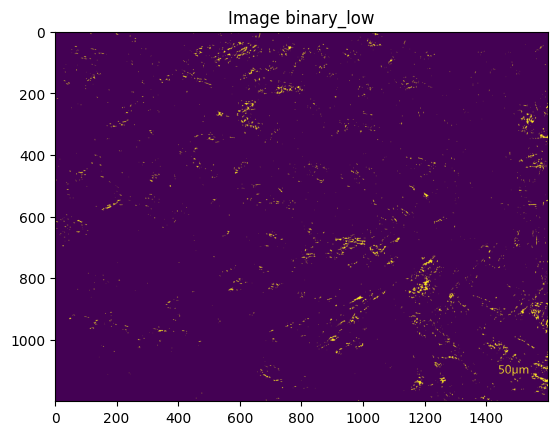

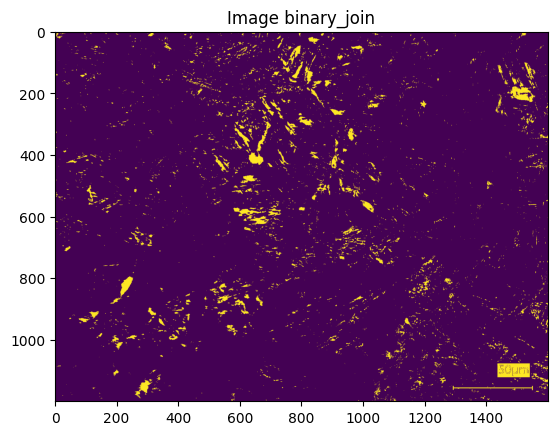

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


threshold = 225
binary = np.where(gray > threshold, 255, 0).astype(np.uint8)
threshold_low = 80
binary_low = np.where(gray < threshold_low, 255, 0).astype(np.uint8)

plt.figure()
plt.imshow(gray,cmap='gray')
plt.title("Image 1")

plt.figure()
plt.imshow(binary)
plt.title("Image binary_high")

plt.figure()
plt.imshow(binary_low)
plt.title("Image binary_low")


plt.figure()
plt.imshow(cv2.bitwise_or(binary_low, binary))
plt.title("Image binary_join")

plt.show()


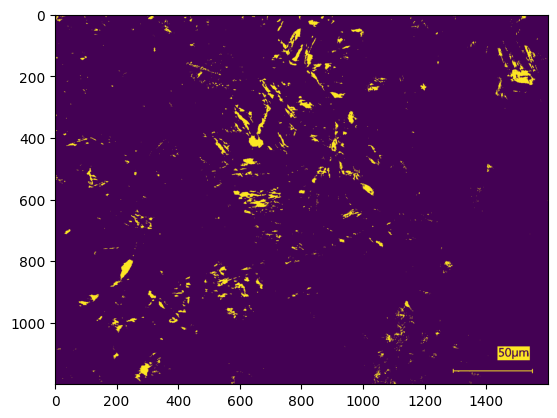

In [5]:
img = binary.copy()

imgA_bin = np.where(binary == 255, 1, 0)
plt.imshow(imgA_bin)

In [49]:
bins_rows, bins_col = imgA_bin.shape
hists = []
for row in imgA_bin:
    hist, bin_edges = np.histogram(row, bins=bins_col)
    hists.append(hist)

In [50]:
import matplotlib.pyplot as plt

bins_rows, bins_col = img.shape

for i, row in enumerate(img):
    plt.hist(row, bins=bins_col, alpha=0.5, label=f"row {i}")
    if i == 3:
        break

plt.legend()
plt.show()

KeyboardInterrupt: 

In [79]:
new_img = np.zeros_like(imgA_bin)
len(imgA_bin[200])

1600

In [75]:
coords = np.nonzero(imgA_bin[200])
coords

(array([  82,   83,  443,  444,  459,  466,  467,  468,  469,  831,  832,
         833,  834,  835,  836,  837,  838,  839,  840,  841,  842,  843,
         844,  845, 1128, 1468, 1469, 1470, 1471, 1472, 1473, 1474, 1478,
        1479, 1480, 1481, 1482, 1483, 1484, 1485, 1486, 1487, 1488, 1489,
        1490, 1491, 1492, 1493, 1494, 1495, 1496, 1500, 1501, 1502, 1503,
        1504, 1505, 1506, 1507, 1508, 1509, 1510, 1512, 1513, 1514, 1515,
        1516, 1517, 1531, 1533, 1540, 1541, 1542, 1543, 1544]),)

(array([ 2.,  0.,  7.,  0.,  0., 15.,  0.,  1.,  0., 50.]),
 array([  82. ,  228.2,  374.4,  520.6,  666.8,  813. ,  959.2, 1105.4,
        1251.6, 1397.8, 1544. ]),
 <BarContainer object of 10 artists>)

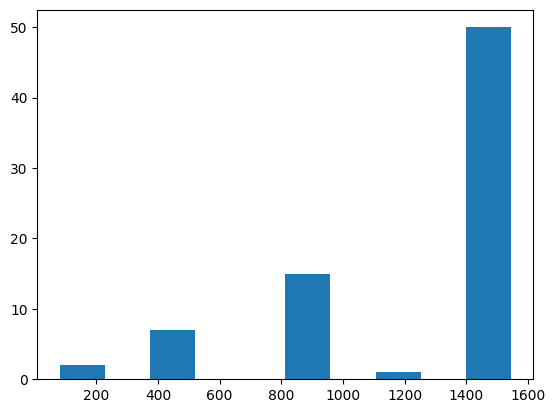

In [53]:
plt.hist(coords)

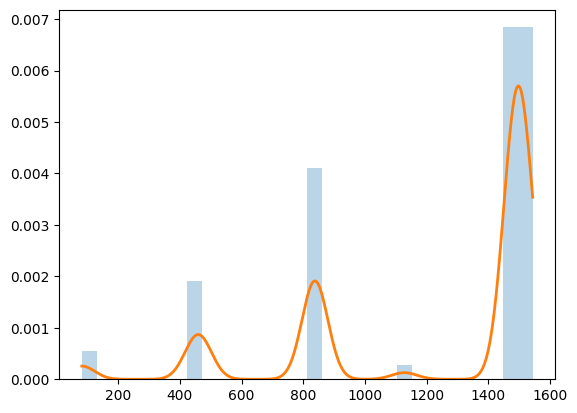

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


kde = gaussian_kde(coords[0], bw_method=0.1)

# Evaluation grid
x = np.linspace(coords[0].min(), coords[0].max(), 1000)
y = kde(x)

# Plot
plt.hist(coords, bins=30, density=True, alpha=0.3)
plt.plot(x, y, linewidth=2)
plt.show()

In [ ]:
import numpy as np
from scipy.stats import gaussian_kde

def get_bin_density(data, bin_centers, n=1600, bw=0.1):
    data = np.asarray(data)
    data = data[np.isfinite(data)]

    if data.size < 2 or np.std(data) == 0:
        return np.zeros(len(bin_centers))

    try:
        kde = gaussian_kde(data, bw_method=bw)
        x = np.linspace(data.min(), data.max(), n)
        y = kde(x)
        return y
    except np.linalg.LinAlgError:
        return np.zeros(len(bin_centers))

# import matplotlib.pyplot as plt

# plt.hist(data, bins=1600, density=True, alpha=0.3)
# plt.plot(bin_centers, bin_densities, 'o-', label="KDE per bin")
# plt.legend()
# plt.show()


In [115]:
def get_bin_density_weighted(data_points, weights, bin_centers, bw=0.1):
    data_points = np.asarray(data_points)
    weights = np.asarray(weights)
    bin_centers = np.asarray(bin_centers)

    # Filter out any NaNs or infs in data_points or weights
    mask = np.isfinite(data_points) & np.isfinite(weights)
    data_points = data_points[mask]
    weights = weights[mask]

    if data_points.size < 2 or np.std(data_points) == 0:
        return np.zeros(len(bin_centers))

    kde = gaussian_kde(data_points, weights=weights, bw_method=bw)
    return kde(bin_centers)

In [116]:
global_min = np.min(imgA_bin)
global_max = np.max(imgA_bin)

bin_edges = np.linspace(global_min, global_max, 1601)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


new_img = np.zeros((imgA_bin.shape[0], len(bin_centers)))

for i, row in enumerate(imgA_bin):
    new_img[i] = get_bin_density_weighted(bin_centers, row, bin_centers)
    # plt.hist(new_img[i], bins=1600, density=True, alpha=0.3)
    # counts, bin_edges = np.histogram(new_img[i], bins=1600, density=True)
    # bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    # plt.plot(bin_centers, new_img[i], 'o-', label="KDE per bin")
    # plt.legend()
    # plt.show()
    # break

ValueError: array must not contain infs or NaNs

In [99]:
np.unique(new_img[1000])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24])

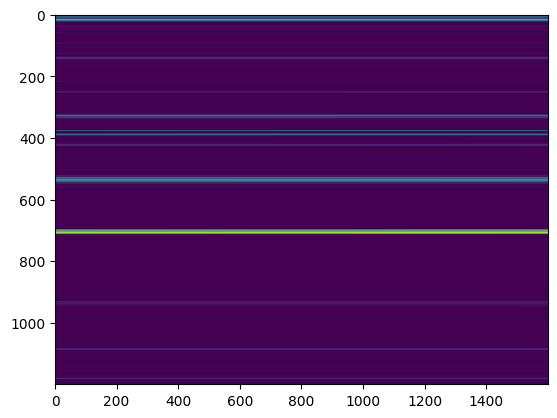

In [ ]:
plt.imshow(new_img)

In [88]:
np.unique(new_img)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  62,  64,  65,  67,
        68,  70,  71,  72,  74,  75,  78,  79,  80,  82,  84,  86,  89,
        91,  93, 102, 108, 112, 130, 148, 157])